In [ ]:
# 모듈 불러오기
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score, 
    recall_score, 
    f1_score
)
import plotly.graph_objects as go
from xgboost import XGBClassifier
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 데이터 불러오기

In [2]:
df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])

C:\Users\Cho\AppData\Local\Temp\ipykernel_15512\288974645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])


In [3]:
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 1
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 1
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 1
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 1
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1 
		"issue_d", "earliest_cr_line",
]

# 중복 검증
df = df[use_col].copy()

In [ ]:
# 파생컬럼 

# 대출 승인 날짜: 년, 월 분리
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str)

# 신용계좌 개설 날짜 : 년 단위 컬럼 생성
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

# 월 상환 부담율(installment_to_income) 생성 
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12)

# 대출규모 대비 소득(loan_to_income) 생성
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] 

# 회전부채 대비 소득(revol_bal_to_income) 생성
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

# 숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income','revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])


print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}") # >> 42 정상

전체: 42
고유: 42


## 모델 작업용 데이터 셋 생성

In [ ]:
df2 = df.copy()

## 모델링 시작 (XGBoost)

In [ ]:
# X, y 분리
y = df2["target"]
X = df2.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 파생변수 결측값 채우기(★train/test 이후 결측값 채우기)
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    train_median = X_train[col].median()                    # train으로만 계산
    X_train[col] = X_train[col].fillna(train_median)       # train에 적용
    X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 


# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_rcnt_il = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_rcnt_il)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_rcnt_il)

# ★train/test 이후 전처리
# dti "sub_grade" 사용해야함 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)
    
# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [7]:
#결측치 최종 검증(값 있는지 확인)
print(X_train.isna().sum().sort_values(ascending = False).head(5))
print(X_test.isna().sum().sort_values(ascending = False).head(5))


loan_amnt    0
term         0
int_rate     0
sub_grade    0
purpose      0
dtype: int64
loan_amnt    0
term         0
int_rate     0
sub_grade    0
purpose      0
dtype: int64


In [ ]:
# 피처별 타입 정의

# 수치형 피처
num_cols = [
    'loan_amnt', 'int_rate', 'issue_year', 'dti', 'fico_mid', 'pub_rec',
    'avg_cur_bal', 'revol_util', 'total_rev_hi_lim', 'bc_open_to_buy',
    'total_bc_limit', 'tot_hi_cred_lim', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_rev_tl_bal_gt_0', 'num_il_tl', 'total_acc', 'acc_open_past_24mths',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_il_acct',
    'mths_since_recent_bc', 'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_delinq', 'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq', 'mths_since_recent_bc_dlq',
    'pct_tl_nvr_dlq', 'issue_month', 'earliest_cr_line_year',
    # 파생변수
    'installment_to_income', 'loan_to_income', 'revol_bal_to_income'
]

# 문자형 피처(범주형)
cat_cols = [
    'term', 'sub_grade', 'purpose', 'emp_length', 'home_ownership',
    # flag 컬럼
    'mths_since_last_major_derog_flag', 'mths_since_recent_inq_flag'
]


used_cols = set(num_cols) | set(cat_cols)
dropped_cols = set(X_train.columns) - used_cols
print(f"제외된 컬럼 수: {len(dropped_cols)}")
print(dropped_cols)

제외된 컬럼 수: 0
set()


In [ ]:
# 파이프 라인 생성 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

num_pipeline = "passthrough"

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist", # 학습 때 없던 새 카테고리 -> 에러 대신 희귀값으로 처리
        min_frequency=0.01 # 전체 1% 미만인 희귀 카테고리는 묶어서 처리
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        tree_method="hist", 
        eval_metric="auc", 
        scale_pos_weight=scale_pos_weight, 
        max_depth=6, # 하이퍼 파라미터 [4, 6]
        n_estimators=500, # 하이퍼 파라미터 [300, 500]
        learning_rate=0.05, # 하이퍼 파라미터 [0.03, 0.05]
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3, 
        gamma=0.1,
        random_state=42
    ))
])

# 전체 데이터로 바로 학습
pipe.fit(X_train, y_train)
print("학습 완료!")

학습 완료!


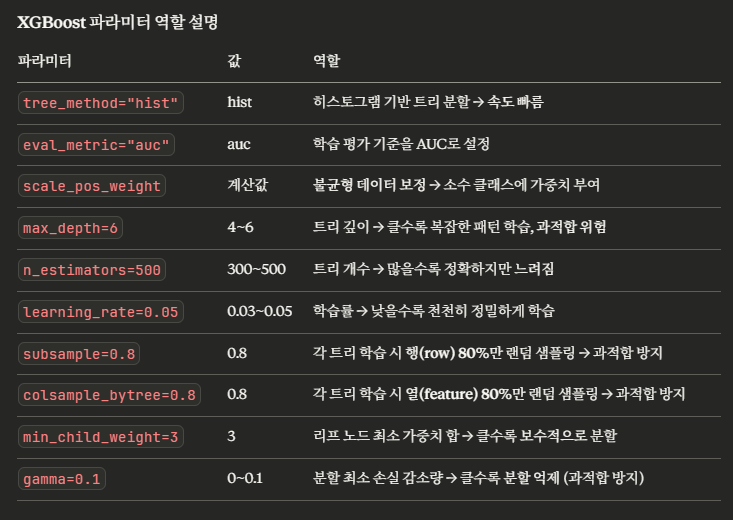

In [17]:
# 평가
y_prob = pipe.predict_proba(X_test)[:, 1]
threshold = 0.5
pred = (y_prob >= threshold).astype(int)

print("\nTest Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, pred))



Test Accuracy: 0.6662153701674753
ROC-AUC: 0.738100210892725
PR-AUC: 0.4199537421582805

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.66      0.76    203905
         1.0       0.34      0.68      0.45     51655

    accuracy                           0.67    255560
   macro avg       0.61      0.67      0.61    255560
weighted avg       0.78      0.67      0.70    255560



## Feature Importance

In [24]:
# feature importance 확인
feature_names = pipe[:-1].get_feature_names_out()
importances = pipe['model'].feature_importances_

importance_df = pd.DataFrame({
    '컬럼': feature_names,
    '중요도': importances
}).sort_values('중요도', ascending=False).reset_index(drop=True)

print(importance_df.head(30))

                                   컬럼       중요도
0                cat__term_ 60 months  0.182099
1                       num__int_rate  0.125483
2                cat__term_ 36 months  0.077636
3                   cat__sub_grade_A1  0.046903
4   cat__sub_grade_infrequent_sklearn  0.030775
5        cat__home_ownership_MORTGAGE  0.027998
6                   cat__sub_grade_A2  0.027212
7             cat__emp_length_unknown  0.026709
8                     num__issue_year  0.023462
9            cat__home_ownership_RENT  0.023373
10                      num__fico_mid  0.020801
11                  cat__sub_grade_A3  0.018311
12          num__acc_open_past_24mths  0.015869
13                num__loan_to_income  0.012480
14                  cat__sub_grade_A4  0.011951
15         num__installment_to_income  0.010665
16               num__num_actv_rev_tl  0.010636
17                   num__avg_cur_bal  0.010041
18                   num__issue_month  0.009971
19                           num__dti  0

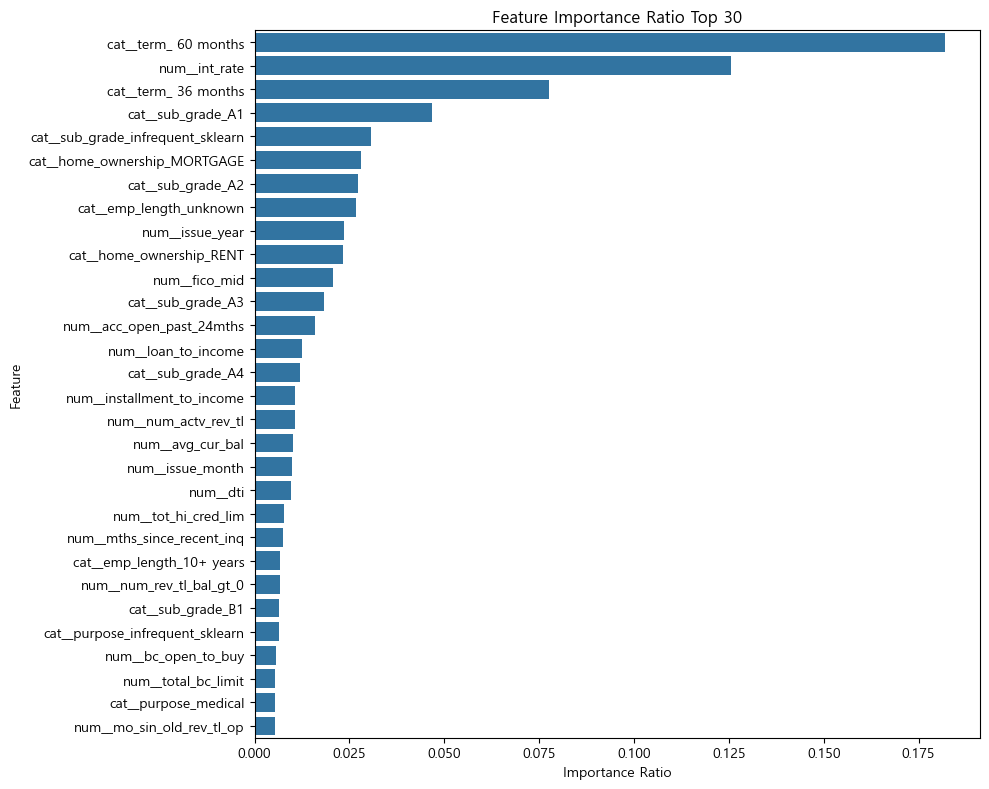

In [ ]:
# feature importance 추출
feature_names = pipe[:-1].get_feature_names_out()
importances = pipe["model"].feature_importances_

importance_df = pd.DataFrame({
    "컬럼": feature_names,
    "중요도": importances
}).sort_values("중요도", ascending=False).reset_index(drop=True)

importance_df["중요도비율"] = importance_df["중요도"] / importance_df["중요도"].sum()

top_n = 30
plot_df = importance_df.head(top_n).copy()

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x="중요도비율", y="컬럼")
plt.title(f"Feature Importance Ratio Top {top_n}")
plt.xlabel("Importance Ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Shap

In [ ]:
# preprocess 스텝만 사용 (smote는 학습 전용이라 제외)
X_test_transformed = pipe.named_steps["preprocess"].transform(X_test)

# 모델 추출
model = pipe.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

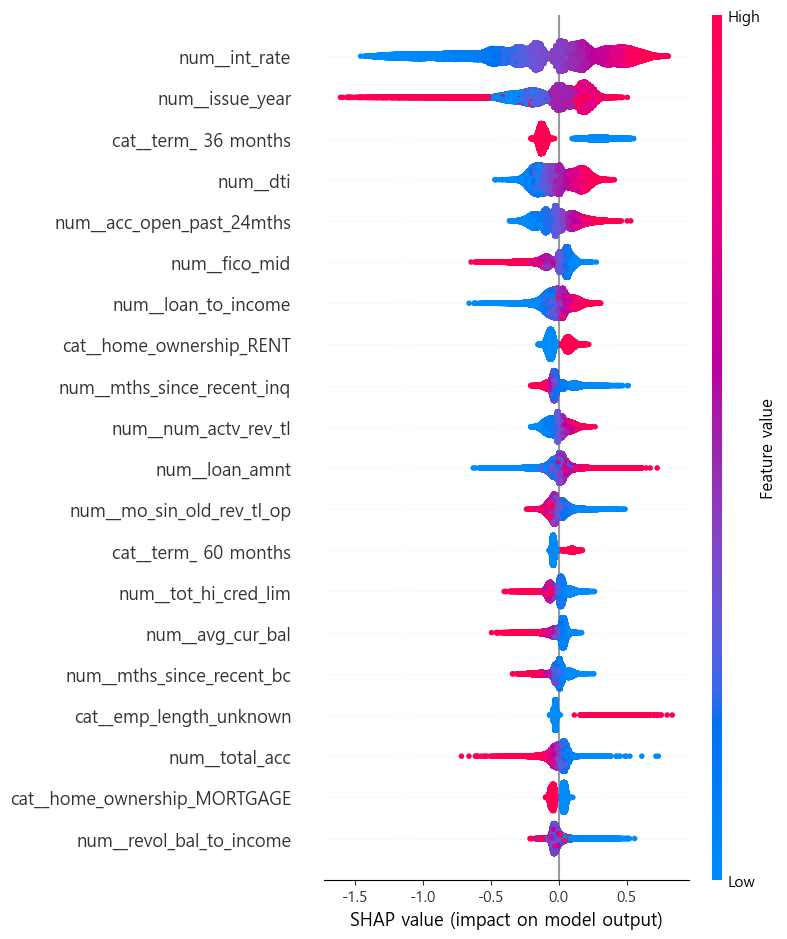

In [ ]:
# shap summary plot 출력
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### shap 양수이면 부도 위험 증가, 음수면 부도 위험 감소 / 색상 빨강색 X값 높음, 파랑색 X값 낮음

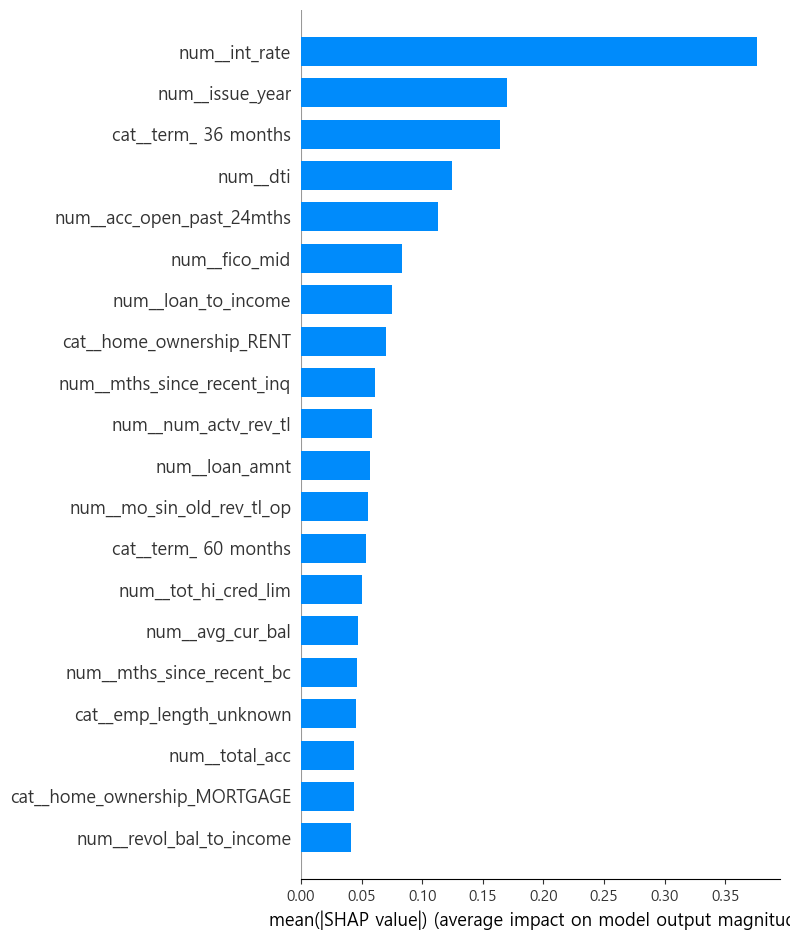

In [ ]:
# shap의 피처 임포턴스
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

[F1 최대] thr=0.50  P=0.338  R=0.682  F1=0.452
[Recall≥0.9] thr=0.30  P=0.256  F1=0.400


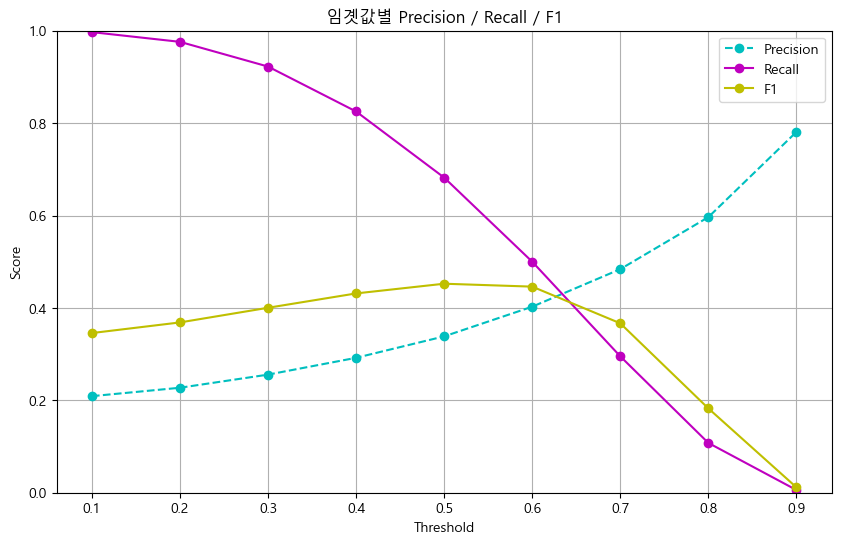

In [ ]:
# ============================================
# 임곗값별 Precision / Recall / F1 템플릿
# 어떤 모델이든 y_test와 y_proba만 있으면 바로 사용
# ============================================


# ── ① 여기만 바꾸면 됨 ──
y_test
y_proba = y_prob  # 양성 확률

# ── ② 임곗값별 지표 계산 ──
thr_list = np.round(np.arange(0.1, 1.0, 0.1), 2)
rows = []
for thr in thr_list:
    y_hat = (y_proba >= thr).astype(int)
    rows.append([thr,
                 precision_score(y_test, y_hat, zero_division=0),
                 recall_score(y_test, y_hat, zero_division=0),
                 f1_score(y_test, y_hat, zero_division=0),
                 accuracy_score(y_test, y_hat)])

thr_df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","accuracy"])

# ── ③ F1 최대 / Recall 목표 자동 출력 ──
best = thr_df.iloc[thr_df["f1"].idxmax()]
print(f"[F1 최대] thr={best['threshold']:.2f}  P={best['precision']:.3f}  R={best['recall']:.3f}  F1={best['f1']:.3f}")

target_recall = 0.90   # ← 원하는 Recall 기준
cand = thr_df[thr_df["recall"] >= target_recall].sort_values("threshold", ascending=False)
print(f"[Recall≥{target_recall}]",
      "없음" if cand.empty else f"thr={cand.iloc[0]['threshold']:.2f}  P={cand.iloc[0]['precision']:.3f}  F1={cand.iloc[0]['f1']:.3f}")

# ── ④ 시각화 ──
plt.figure(figsize=(10, 6))
plt.plot(thr_df["threshold"], thr_df["precision"], "c--o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], "m-o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], "y-o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("임곗값별 Precision / Recall / F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()